# Diagnostics of the fitted spatial BMCD — simulation vs observation

Companion of [spatial_analysis_article.ipynb](spatial_analysis_article.ipynb): the pipeline notebook fits the spatial model of [main.tex](../Spatialisation-Rain-Occurrence-Generator-article/main.tex) (per-station BMCD exit probabilities + latent Gaussian field with exponential correlation of range $\sigma$, estimated by pairwise composite MLE). This notebook takes the fitted model ($\hat\sigma$ and the per-station single-site fits) and asks **how close simulations from it are to the observed ECAD occurrence field**.

All function bodies live in [spatial_diagnostics.py](spatial_diagnostics.py). Diagnostics (one section each):

1. **Occurrence raster with spatially ordered stations** — do nearby stations share wet/dry (and *heavy dry*) episodes, visually?
2. **Pairwise co-occurrence vs distance** — does the simulated distance-decay of dependence match the observed one?
3. **Heavy-dry-spell synchrony** — are long dry spells as spatially synchronous as observed?
4. **Daily wet-fraction distribution** — is the whole-field coherence (beyond pairs) right?
5. **Spell-duration survival curves** — are the single-site duration distributions preserved by the spatial layer?
6. **Sensitivity to the missing-data pattern** — do the conclusions change if simulations are masked like the observations?

## Methodology

**Block layout.** Write the observed occurrence matrix as $R \in \{0,1,\mathrm{NaN}\}^{N \times J}$, where $R_{n,j}$ is the state of station $j$ on day $n$ ($0$ = dry, $1$ = wet, NaN = missing), $n = 0,\dots,N-1$, $j = 1,\dots,J$. It is split into $B = 41$ disjoint per-year blocks: block $b$ gathers the $L = 92$ spring days of one calendar year and starts at day index $t_b$, so it spans days $t_b, t_b+1, \dots, t_b+L-1$ (with $t_{b+1} > t_b + L - 1$). The block is the $L \times J$ slice
$$
R^{(b)} \in \{0,1,\mathrm{NaN}\}^{L \times J}, \qquad R^{(b)}_{u,j} = R_{\,t_b + u,\,j}, \quad u = 0,\dots,L-1, \quad b = 1,\dots,B,
$$
over the $J = 35$ stations, and we collect them into $\mathcal{R} := (R^{(1)}, \dots, R^{(B)})$.

A *diagnostic* is a functional $T$ that takes such a whole collection of blocks and pools information across all $B$ blocks and all $J$ stations — e.g. a co-occurrence-vs-distance curve, or a survival function — so $T(\mathcal{R})$ is a single (possibly vector- or curve-valued) summary of the entire record, not of one block or one station. Each $T$ is evaluated by the *same* code on the observed collection $\mathcal{R}$ and on every simulated collection $\tilde{\mathcal{R}}^{(m)}$ (defined below); the observed value $T(\mathcal{R})$ is then compared with the empirical distribution of the ensemble $\bigl\{\, T(\tilde{\mathcal{R}}^{(m)}) \,\bigr\}_{m=1}^{M}$ ($M = 20$ replicates), summarised by its pointwise $2.5\text{–}97.5\%$ band — where $T(\mathcal{R})$ should fall if the fitted model were the truth.

**Seasonality.** The model is fitted on spring only, so the exit probabilities $q^{(0)}_{\mathbf{s}_j}, q^{(1)}_{\mathbf{s}_j}$ and $\hat\sigma$ are time-invariant: the fitted process is stationary (a "perpetual spring" process), with no $\text{March}\!\to\!\text{May}$ drift. The observed record, by contrast, is a union of disjoint $L$-day windows: the spell in progress at the start day $t_b$ of block $b$ began in winter (its age is unknown), and distinct blocks are effectively independent.

**Simulated ensemble.** The stationary law is the spatial BMCD of Section 5: an i.i.d. daily latent field
$$
Y_n \overset{\text{iid}}{\sim} \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma}), \qquad (\boldsymbol{\Sigma})_{jj'} = \exp\!\bigl(-\|\tilde{\mathbf{s}}_j - \tilde{\mathbf{s}}_{j'}\|/\hat\sigma\bigr),
$$
pushed through the per-station exit probabilities to the occupancy $R_{n,j}$. For each replicate $m = 1,\dots,M$ a *single* long trajectory $R^{(m)} \in \{0,1\}^{N_m \times J}$ of length $N_m = n_{\text{burn}} + B L + (B-1)g$ is drawn (`simulate_cholesky`); the first $n_{\text{burn}} = 2000$ days are discarded (removing the all-dry initialisation and reaching the stationary regime) and $B$ windows of length $L$ are cut out, separated by $g = 500$ discarded days, giving the $m$-th simulated collection $\tilde{\mathcal{R}}^{(m)} := (\tilde R^{(1,m)}, \dots, \tilde R^{(B,m)})$ with
$$
\tilde R^{(b,m)}_{u,j} = R^{(m)}_{\,n_{\text{burn}} + (b-1)(L+g) + u,\ j}, \qquad u = 0,\dots,L-1.
$$
The gaps make consecutive blocks effectively independent even for heavy-tailed dry spells; one long run pays the burn-in once, under the same stationary law as $B$ independent runs.

**Symmetric censoring.** Quantities involving spell ages or durations are recomputed from the binary values on both sides with identical rules — ages restart at each block start and after every NaN, and spells touching a block edge are dropped — so the season-window censoring applies the same way to observations and simulations. In particular the **censored dry-spell age** $\tilde{D}_{n,j}$ counts the consecutive dry days up to and including day $n$ *within the current block*,
$$
\tilde{D}_{n,j} =
\begin{cases}
0, & R_{n,j} = 1, \\[2pt]
1, & R_{n,j} = 0 \text{ and } \bigl(n = t_b \text{ for some } b,\ \text{or } R_{n-1,j} = \mathrm{NaN}\bigr), \\[2pt]
\tilde{D}_{n-1,j} + 1, & R_{n,j} = 0 \text{ otherwise},
\end{cases}
$$
so that $\tilde{D}_{n,j} \le D_{n,j}$ (the uncensored age), with equality when the current spell started inside the block.

**Missing data.** Diagnostics are first computed on the full simulated blocks (no missing values). Section 6 repeats the key ones after copying the observed NaN pattern onto each replicate, $\tilde R^{(b,m)}_{u,j} \leftarrow \mathrm{NaN}$ wherever $R^{(b)}_{u,j} = \mathrm{NaN}$, which forces identical index sets on both sides: the per-station record set $\mathcal{T}_j$ (days at which $j$ records), the joint sets $\mathcal{T}_j \cap \mathcal{T}_{j'}$, and the per-day recording set $\mathcal{O}_n$ (stations recording on day $n$).

**Notation.** Symbols follow the article: $R_{n,j} \in \{0,1\}$ (NaN when missing), $\mathcal{T}_j$, $\mathcal{O}_n$, the rescaled coordinates $\tilde{\mathbf{s}}_j$, and $(\boldsymbol{\Sigma})_{jj'} = \exp(-\|\tilde{\mathbf{s}}_j - \tilde{\mathbf{s}}_{j'}\|/\hat\sigma)$ the fitted latent correlation. The only added symbol is the censored dry-spell age $\tilde{D}_{n,j}$ defined above. Hatted quantities are empirical estimates, computed by the same code on observed and simulated blocks.

In [2]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from article_code.util_files import config
from spatial_bmcd.archive_old_single_latent_field.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    load_all_station_rr,
    build_joint_df_occurrence_from_raw_data,
)
from spatial_bmcd.archive_old_single_latent_field.spatial_diagnostics import (
    blocks_from_Rbin,
    simulate_block_ensemble,
    mask_like_obs,
    spatial_station_order,
    pairwise_occurrence_stats,
    heavy_dry_stats,
    daily_wet_fraction,
    heavy_dry_daily_fraction,
    plot_station_order_map,
    plot_occurrence_raster_obs_vs_sim,
    plot_pairwise_stat_vs_distance,
    plot_fraction_distribution,
    plot_spell_survival_obs_vs_sim,
)

# Same data selection as the pipeline notebook.
COUNTRIES = ["PT", "ES"]
SEASON = "spring"
YEAR_MIN, YEAR_MAX = 1980, 2020

# A dry spell is "heavy" once its running age reaches this many days.
HEAVY_DRY_MIN_DAYS = 20

# sigma_hat fitted in spatial_analysis_article.ipynb ("Real-data estimation on ECAD").
# Set REFIT = True to recompute it here instead (takes a few minutes).
SIGMA_HAT = 0.3197
REFIT = False

In [3]:
# Reload the single-site fits and the observed occurrence matrix (same steps as
# the pipeline notebook, condensed).
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)

stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
    df_fit_dry, df_fit_wet, stations_used, countries=COUNTRIES, season=SEASON,
)
dict_model_params = build_dict_model_params(
    df_fit_dry_sub, df_fit_wet_sub, spells, season=SEASON, show_progress=False,
)

stations_to_get = sorted(dict_model_params.keys())
dfs_by_city = load_all_station_rr(
    data_dir=config.ECAD_RAW_DIR, stations_to_get=stations_to_get, verbose=False,
)
stations_to_get = [c for c in stations_to_get if c in dfs_by_city]
Rbin = build_joint_df_occurrence_from_raw_data(
    dfs_by_city, season=SEASON, station_names=stations_to_get,
    wet_day_threshold=float(config.WET_DAY_THRESHOLD),
)
Rbin = Rbin.loc[(Rbin.index.year >= YEAR_MIN) & (Rbin.index.year <= YEAR_MAX)]

station_names = list(Rbin.columns)
params_by_station = {c: dict_model_params[c] for c in station_names}
print(f"Rbin: {Rbin.shape} (days x stations), {len(params_by_station)} stations")

if REFIT:
    from spatial_bmcd.archive_old_single_latent_field.spatial_model import (
        history_from_Rbin_drop_ambiguous_spell_after_nan,
        split_history_by_year,
        mle_sigma_pairwise_histories,
    )
    histories = split_history_by_year(history_from_Rbin_drop_ambiguous_spell_after_nan(Rbin))
    SIGMA_HAT = mle_sigma_pairwise_histories(
        histories, params_by_station, bounds=(1e-3, 5.0), vectorized=True
    )["sigma_hat"]
print(f"sigma_hat = {SIGMA_HAT:.4f}")

Rbin: (3772, 35) (days x stations), 35 stations
sigma_hat = 0.3197


## Observed blocks & simulated ensemble

Build the observed block collection $\mathcal{R} = (R^{(1)}, \dots, R^{(B)})$ ($B = 41$ per-year blocks, each $L = 92$ days $\times$ $J = 35$ stations) from `Rbin`, then draw the $M = 20$ simulated collections $\tilde{\mathcal{R}}^{(m)} = (\tilde R^{(1,m)}, \dots, \tilde R^{(B,m)})$ with the same layout from the fitted stationary model (see *Methodology* above for the definitions of $t_b$, the burn-in and the gap):
$$
R^{(b)}_{u,j} = R_{\,t_b + u,\,j}, \qquad
\tilde R^{(b,m)}_{u,j} = R^{(m)}_{\,n_{\text{burn}} + (b-1)(L+g) + u,\ j}, \qquad u = 0,\dots,L-1,
$$
with one `simulate_cholesky` run $R^{(m)}$ per replicate, burn-in $n_{\text{burn}} = 2000$ and discarded gaps $g = 500$ between windows. Each diagnostic $T$ is then compared as the observed $T(\mathcal{R})$ against the ensemble $\bigl\{\, T(\tilde{\mathcal{R}}^{(m)}) \,\bigr\}_{m=1}^{M}$. Takes a few minutes.

In [4]:
M = 1  # ensemble size

obs_blocks = blocks_from_Rbin(Rbin)
n_blocks = len(obs_blocks)
lens = {b["R"].shape[0] for b in obs_blocks}
assert len(lens) == 1, f"non-uniform block lengths: {lens}"
block_len = lens.pop()

sims = simulate_block_ensemble(
    sigma=SIGMA_HAT,
    params_by_station=params_by_station,
    n_blocks=n_blocks,
    block_len=block_len,
    n_sims=M,
    n_burn=2000,
    gap=500,
    seed=5,
    station_names=station_names,
)
print(f"{n_blocks} blocks of {block_len} days x {len(station_names)} stations; "
      f"ensemble of {len(sims)} replicates")

Simulating ensemble: 100%|██████████| 1/1 [00:15<00:00, 15.19s/it]

41 blocks of 92 days x 35 stations; ensemble of 1 replicates


### Aside — spatially ordering the stations (seriation)

Several figures below display the $J = 35$ stations as the rows of a 2-D image. The stations are points $\tilde{\mathbf{s}}_j \in [0,1]^2$ on the map, so to use them as an *ordered* axis we must turn that 2-D cloud into a 1-D sequence in which neighbours in the list are also neighbours on the map. Formally, we look for a permutation $\pi$ of $\{1,\dots,J\}$ that minimises the total length of the path visiting the stations in that order,

$$
\min_{\pi}\;\sum_{k=1}^{J-1} \bigl\|\tilde{\mathbf{s}}_{\pi(k)} - \tilde{\mathbf{s}}_{\pi(k+1)}\bigr\|,
$$

a 1-D embedding of the distance matrix $D_{jj'} = \|\tilde{\mathbf{s}}_j - \tilde{\mathbf{s}}_{j'}\|$. This is the **minimal Hamiltonian-path-length** seriation criterion — equivalently an open-tour travelling-salesman objective on the stations (Hahsler, Hornik & Buchta, 2008, *Journal of Statistical Software* **25**(3), §2.1) — and is NP-hard, so it is *approximated* by **hierarchical clustering with optimal leaf ordering**:

1. **agglomerative clustering** builds a binary tree (dendrogram) bottom-up — start with one cluster per station and repeatedly merge the two closest clusters, "closest" being the average inter-station distance between two clusters (average linkage / UPGMA);
2. each internal node of the tree may swap its two subtrees without changing the clustering, giving $2^{\,J-1}$ equivalent orderings of the leaves; **optimal leaf ordering** picks the swaps that minimise $\sum_{k} D_{\pi(k),\pi(k+1)}$ over the orderings consistent with the dendrogram — the same adjacent-distance sum as above, restricted to a tractable $O(J^3)$ search (Bar-Joseph, Gifford & Jaakkola, 2001, *Bioinformatics* **17**(suppl. 1), S22–S29);
3. reading the leaves left to right yields the permutation $\pi$.

The result is a **seriation** of the distance matrix: reindexing its rows and columns by $\pi$ pushes the small distances towards the diagonal, so geographically close stations end up on adjacent raster rows and a regional episode shows up as a contiguous vertical band rather than scattered pixels. The ordering is computed once by `spatial_station_order(...)` and reused as the common station axis of every raster.

**Implementation.** [SciPy](https://docs.scipy.org/doc/scipy/) `scipy.cluster.hierarchy`: [`linkage(..., method="average", optimal_ordering=True)`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html) — the `optimal_ordering=True` flag implements Bar-Joseph et al. (2001) — followed by [`leaves_list`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.leaves_list.html), applied to the condensed distance matrix produced by [`scipy.spatial.distance.squareform`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.squareform.html).

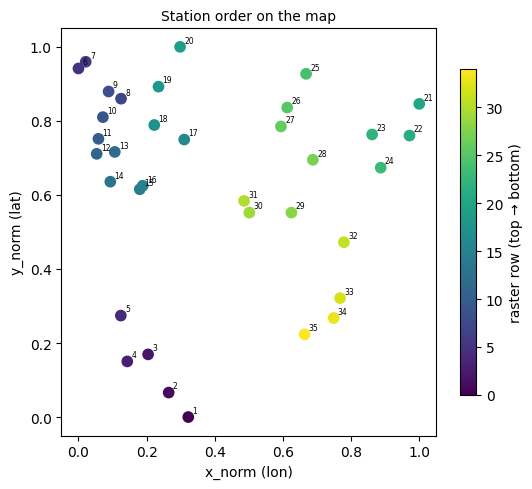

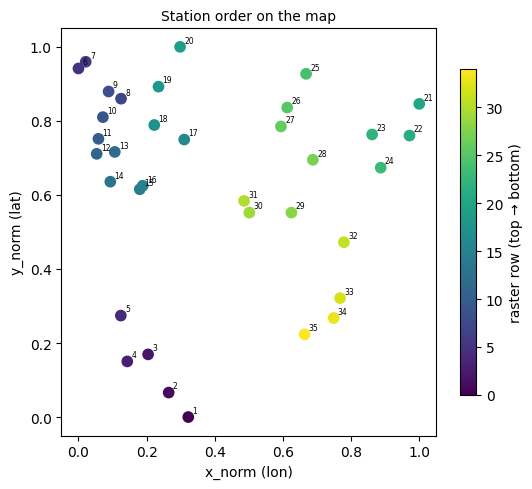

In [5]:
# Spatial order of the stations, reused as the common y-axis of every raster below.
order = spatial_station_order(params_by_station, station_names)
plot_station_order_map(params_by_station, station_names, order=order)

## 1. Occurrence raster with spatially ordered stations

**What is computed.** Each station-day is coloured by the category

$$
c_{n,j} \;=\;
\begin{cases}
\text{wet}, & \text{if } R_{n,j}=1,\\[2pt]
\text{dry}, & \text{if } R_{n,j}=0 \text{ and } \tilde{D}_{n,j} < h,\\[2pt]
\text{heavy dry}, & \text{if } R_{n,j}=0 \text{ and } \tilde{D}_{n,j} \ge h,
\end{cases}
\qquad h = 10 \text{ days},
$$

for the observed seasons (top) and simulated blocks (bottom). The station axis is the same permutation of $1,\dots,J$ on both panels, obtained by seriation of the distance matrix $\bigl(\|\tilde{\mathbf{s}}_j-\tilde{\mathbf{s}}_{j'}\|\bigr)_{j,j'}$ (hierarchical clustering with optimal leaf ordering), so adjacent rows are close on the map — the *Station order on the map* figure above shows where each raster row sits geographically.

**How to read it.** Spatially coherent episodes appear as *vertically contiguous* patches: a regional drought is a dark-red block spanning several adjacent rows, a regional wet episode a blue vertical stripe. Compare the typical size and shape of the patches between the two panels — the simulated panel is one random replicate, not a reconstruction of the observed years, so only the *texture* is comparable.

**What a mismatch means.** Observed patches more vertically coherent than simulated ones $\to$ the fitted spatial dependence is too weak (or a single exponential range cannot capture it); fragmented observed patches with coherent simulated ones $\to$ too strong.

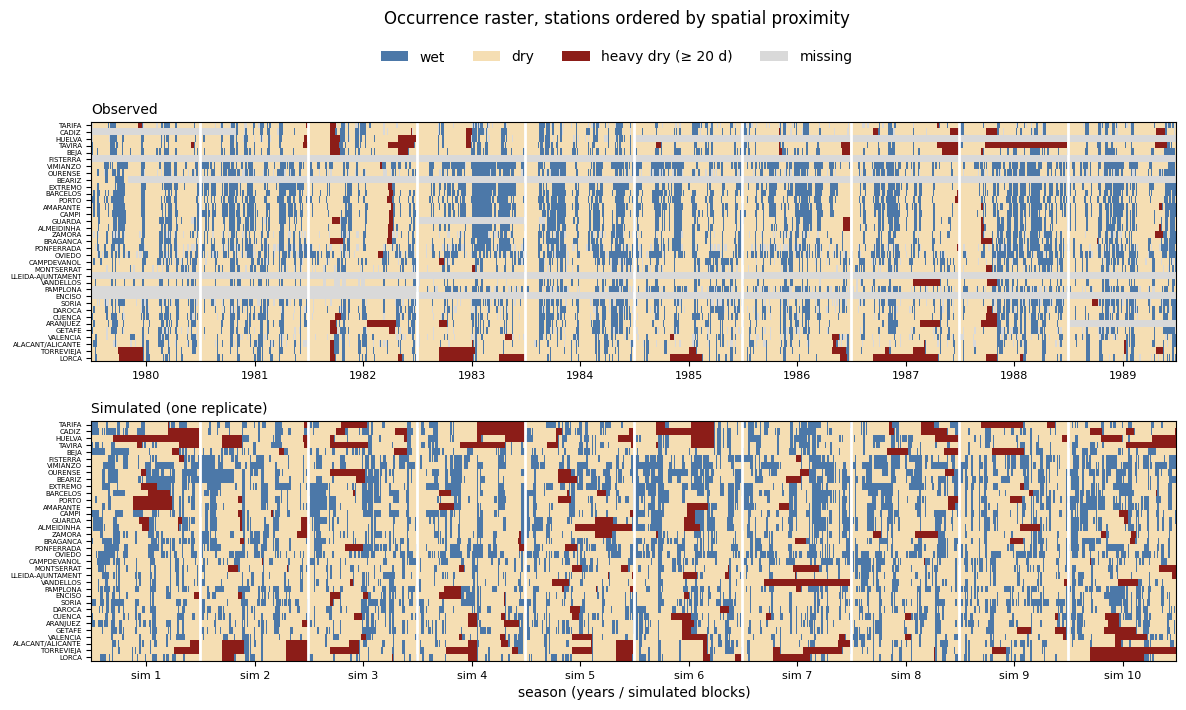

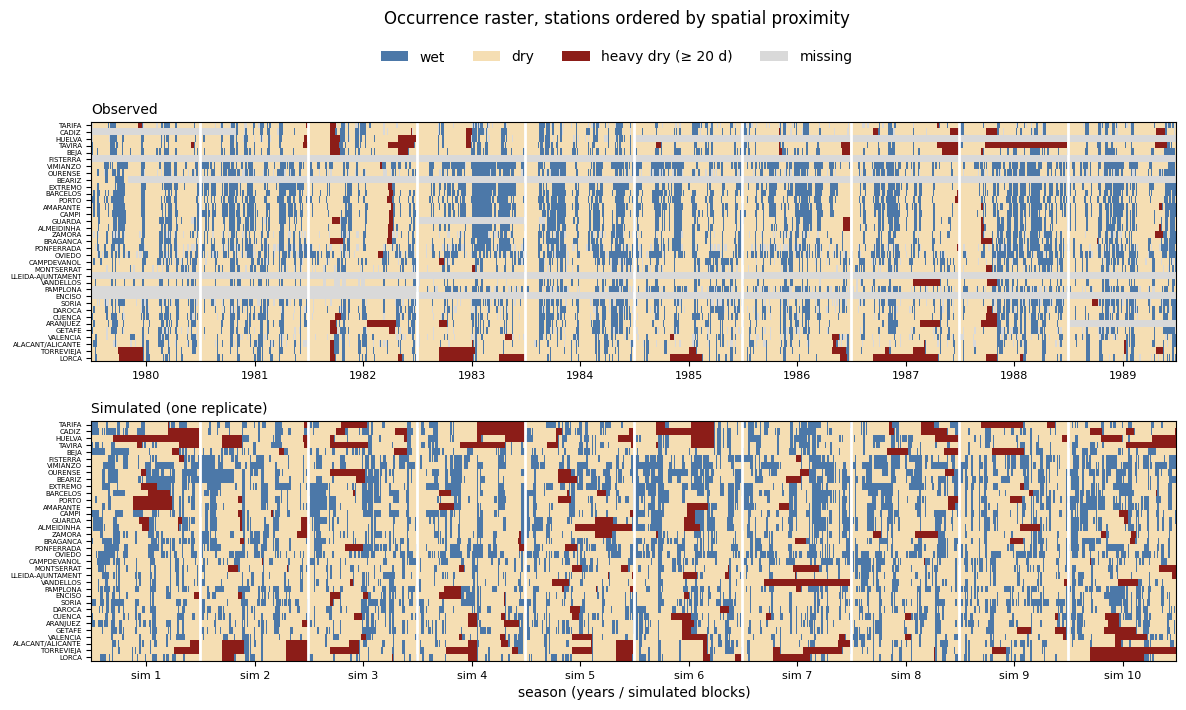

In [6]:
plot_occurrence_raster_obs_vs_sim(
    obs_blocks, sims[0], params_by_station,
    order=order,
    heavy_dry_min_days=HEAVY_DRY_MIN_DAYS,
    n_seasons=10,       # number of seasons shown
    first_season=0,    # change to look at other years
    figsize = (14,7))

## 2. Pairwise co-occurrence vs distance

**What is computed.** For each of the 595 pairs $(j,j')$, over the jointly observed days $n \in \mathcal{T}_j \cap \mathcal{T}_{j'}$ pooled across blocks:

$$
\hat{p}_{11}^{(j,j')} \;=\; \frac{1}{|\mathcal{T}_j \cap \mathcal{T}_{j'}|} \sum_{n \in \mathcal{T}_j \cap \mathcal{T}_{j'}} \mathbf{1}\{R_{n,j}=1\}\,\mathbf{1}\{R_{n,j'}=1\},
\qquad \hat{p}_{00}^{(j,j')} \text{ likewise with } R = 0,
$$

and the empirical correlation of the wet indicators (the $\phi$ coefficient of the $2\times 2$ table; plot label `phi`),

$$
\hat{\phi}_{jj'} \;=\; \frac{\hat{p}_{11}^{(j,j')} - \hat{p}_j\,\hat{p}_{j'}}{\sqrt{\hat{p}_j(1-\hat{p}_j)\;\hat{p}_{j'}(1-\hat{p}_{j'})}},
$$

where $\hat{p}_j$ is the wet frequency of station $j$ over the same days. The same $\phi$ coefficient built from the **dry indicators** $1-R_{n,j}$ (plot label `phi_dry`) is

$$
\hat{\phi}^{\,\mathrm{dry}}_{jj'} \;=\; \frac{\hat{p}_{00}^{(j,j')} - (1-\hat{p}_j)\,(1-\hat{p}_{j'})}{\sqrt{\hat{p}_j(1-\hat{p}_j)\;\hat{p}_{j'}(1-\hat{p}_{j'})}} \;=\; \hat{\phi}_{jj'},
$$

which is *identically equal* to $\hat\phi_{jj'}$: the $\phi$ coefficient is invariant under the $0\!\leftrightarrow\!1$ relabelling since $\mathrm{Corr}(1-X,1-Y)=\mathrm{Corr}(X,Y)$ — the wet- and dry-indicator dependences are the same number, so `phi_dry` doubles as a consistency check of the implementation. Each statistic is plotted against the distance $\|\tilde{\mathbf{s}}_j - \tilde{\mathbf{s}}_{j'}\|$: black dots = observed; blue dots and band = per-pair ensemble means and distance-binned 2.5–97.5% range over the $M$ replicates. Under the model this *same-day* dependence is induced by $(\boldsymbol{\Sigma})_{jj'}$ but has no closed form — unlike the one-day switch probabilities $\Phi_2(z_{n,j}, z_{n,j'};\cdot)$ of the likelihood, it accumulates through the joint history of the two chains — so the simulated band plays the role of the model-implied curve. The dashed line marks $\hat\sigma$, the distance at which the latent correlation $\exp(-\|\tilde{\mathbf{s}}_j - \tilde{\mathbf{s}}_{j'}\|/\hat\sigma)$ equals $1/e$.

**How to read it.** If the model captures the spatial dependence, the black dots scatter inside the blue band at every distance, with the same decay shape.

**What a mismatch means.** This is the most direct check of the dependence structure the pairwise MLE fitted. Observed dots above the band at short distances $\to$ dependence underestimated there (a nugget-free exponential may be too rigid); above the band at long distances only $\to$ one range parameter cannot capture the long-range dependence (consider Matérn, anisotropy). $\hat{p}_{11}$ and $\hat{p}_{00}$ also reflect the per-station marginals, while $\hat\phi$ (equivalently $\hat\phi^{\,\mathrm{dry}}$) isolates the dependence.

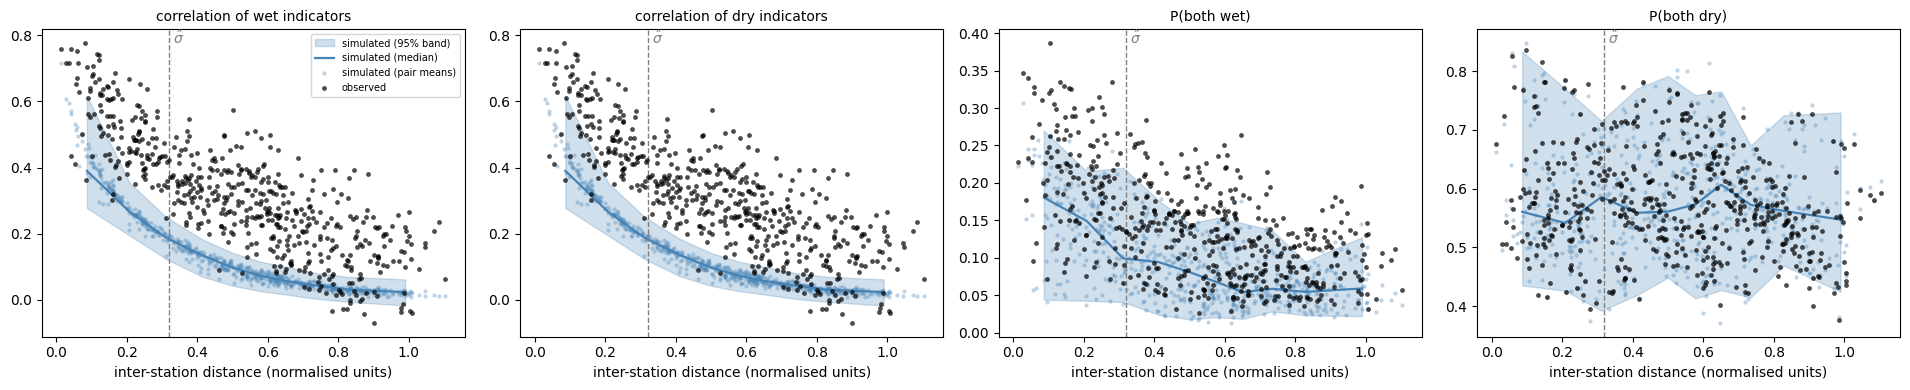

In [6]:
obs_pairs = pairwise_occurrence_stats(obs_blocks, params_by_station)
sim_pairs = [pairwise_occurrence_stats(bl, params_by_station) for bl in sims]

plot_pairwise_stat_vs_distance(
    obs_pairs, sim_pairs,
    stats=("phi", "phi_dry", "p11", "p00"),
    sigma_marker=SIGMA_HAT,
    filename="diag_pairwise_vs_distance.pdf",
);

## 3. Heavy-dry-spell synchrony

**What is computed.** The daily heavy-dry indicator

$$
H_{n,j} \;=\; \mathbf{1}\bigl\{R_{n,j}=0,\ \tilde{D}_{n,j} \ge h\bigr\}.
$$

First, the pairwise construction of section 2 applied to $H$ instead of $R$: for $h = 5$ and $15$,

$$
\hat{p}_{HH}^{(j,j')} \;=\; \frac{1}{|\mathcal{T}_j \cap \mathcal{T}_{j'}|} \sum_{n \in \mathcal{T}_j \cap \mathcal{T}_{j'}} H_{n,j}\,H_{n,j'}
$$

— the empirical probability that both stations are simultaneously in a dry spell of age $\ge h$ — plotted against $\|\tilde{\mathbf{s}}_j - \tilde{\mathbf{s}}_{j'}\|$. Second, the distribution over days of the drought *extent*: the daily share $\frac{1}{|\mathcal{O}_n|}\sum_{j \in \mathcal{O}_n} H_{n,j}$ of stations in a heavy dry spell ($h = 10$; log scale, large extents are rare).

**How to read it.** Black dots inside the band $\to$ joint droughts have the right probability at every distance. In the extent plot the right tail is the key part: the frequency of droughts covering a large share of the region at once.

**What a mismatch means.** The pairwise likelihood is fitted on *one-day transitions*, so multi-day joint behaviour is not directly targeted by the estimation — this is a genuine out-of-fit prediction. An observed right tail above the band means real droughts cover larger areas than the model produces (spatial dependence too weak, and/or the day-to-day independence of the latent fields $Y_n$ is too strong an assumption).

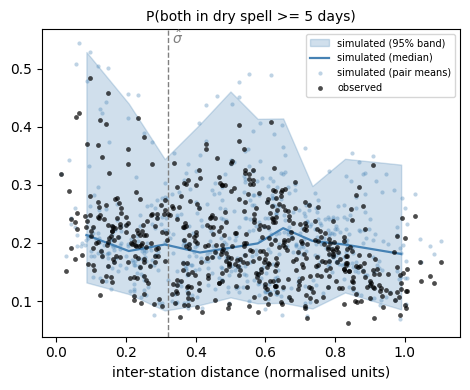

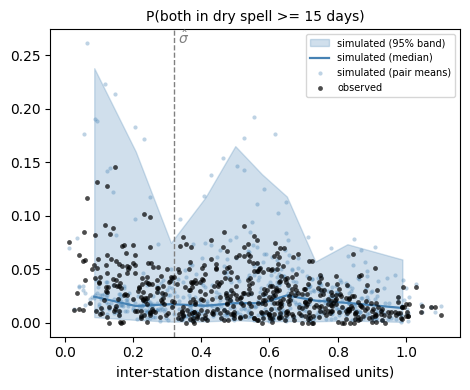

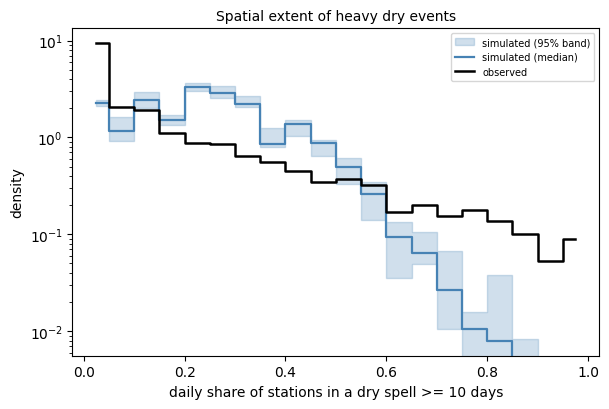

In [7]:
for h in (5, 15):
    obs_h = heavy_dry_stats(obs_blocks, params_by_station, heavy_dry_min_days=h)
    sim_h = [heavy_dry_stats(bl, params_by_station, heavy_dry_min_days=h) for bl in sims]
    plot_pairwise_stat_vs_distance(
        obs_h, sim_h,
        stats=("p11",),
        stat_labels={"p11": f"P(both in dry spell >= {h} days)"},
        sigma_marker=SIGMA_HAT,
        filename=f"diag_heavy_dry_ge{h}_vs_distance.pdf",
    )

# Spatial extent of droughts: daily share of stations in a heavy dry spell.
obs_ext = heavy_dry_daily_fraction(obs_blocks, HEAVY_DRY_MIN_DAYS)
sim_ext = [heavy_dry_daily_fraction(bl, HEAVY_DRY_MIN_DAYS) for bl in sims]
plot_fraction_distribution(
    obs_ext, sim_ext,
    log_y=True,
    xlabel=f"daily share of stations in a dry spell >= {HEAVY_DRY_MIN_DAYS} days",
    title="Spatial extent of heavy dry events",
    filename="diag_heavy_dry_extent.pdf",
);

## 4. Daily wet-fraction distribution

**What is computed.** The daily wet fraction

$$
W_n \;=\; \frac{1}{|\mathcal{O}_n|} \sum_{j \in \mathcal{O}_n} R_{n,j},
\qquad \text{kept when } |\mathcal{O}_n| \ge 10,
$$

and the histogram of $\{W_n\}$ pooled over blocks (observed black steps vs ensemble band). Since $\mathbb{E}[W_n]$ only involves the per-station wet frequencies — matched by construction — the information is in the spread and shape: $\mathrm{Var}(W_n) = |\mathcal{O}_n|^{-2} \sum_{j,j'} \mathrm{Cov}(R_{n,j}, R_{n,j'})$ aggregates *all* pairwise covariances at once, and the full histogram is also sensitive to joint behaviour beyond pairs.

**How to read it.** This summarises the *whole-field* coherence beyond pairs: mass near 0 = region-wide dry days, mass near 1 = region-wide wet days, mass in the middle = patchy days.

**What a mismatch means.** Too little simulated mass at the extremes with too much in the middle $\to$ the simulated field is too patchy (regional-scale dependence too weak) even if the pairwise statistics look fine — and conversely.

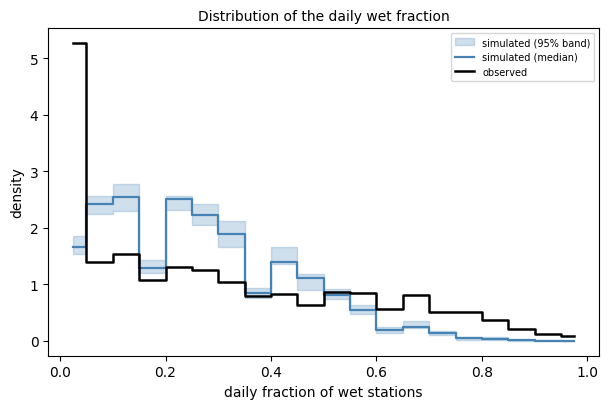

In [8]:
obs_wf = daily_wet_fraction(obs_blocks)
sim_wf = [daily_wet_fraction(bl) for bl in sims]

plot_fraction_distribution(
    obs_wf, sim_wf,
    xlabel="daily fraction of wet stations",
    title="Distribution of the daily wet fraction",
    filename="diag_wet_fraction_hist.pdf",
);

## 5. Spell-duration survival curves

**What is computed.** Within each block and station, the maximal runs of constant $R_{n,j}$ are extracted; runs touching a block edge or a NaN are discarded (their true duration is censored), and the remaining *complete* runs are realisations of the spell durations $\tau^{(r)}_{\mathbf{s}_j}$ of Eq. (1) of the article. Pooling them over stations and blocks, for each spell type $r \in \{0,1\}$ the empirical survival function

$$
\widehat{\overline{F}}{}^{(r)}(d) \;=\; \frac{1}{N^{(r)}} \sum_{i=1}^{N^{(r)}} \mathbf{1}\{\tau_i \ge d\},
\qquad d = 1, 2, \dots,
$$

is drawn on a log scale, where $\tau_1, \dots, \tau_{N^{(r)}}$ are the complete $r$-spells (observed curve vs ensemble band; the identical censoring rule is applied to both sides).

**How to read it.** The observed curve should sit inside the band over the whole range of durations.

**What a mismatch means.** This is a *consistency check* rather than a test of the spatial dependence: at any single station the simulated sojourn times follow the fitted single-site exit probabilities $q^{(r)}_{\mathbf{s}_j}$ exactly, whatever $\sigma$ (each station behaves as the single-site chain by construction, Section 3 of the article). A discrepancy would point at the single-site fits themselves (e.g. dry-spell tail misfit at some stations), at the censoring treatment, or at a bug — not at $\hat\sigma$.

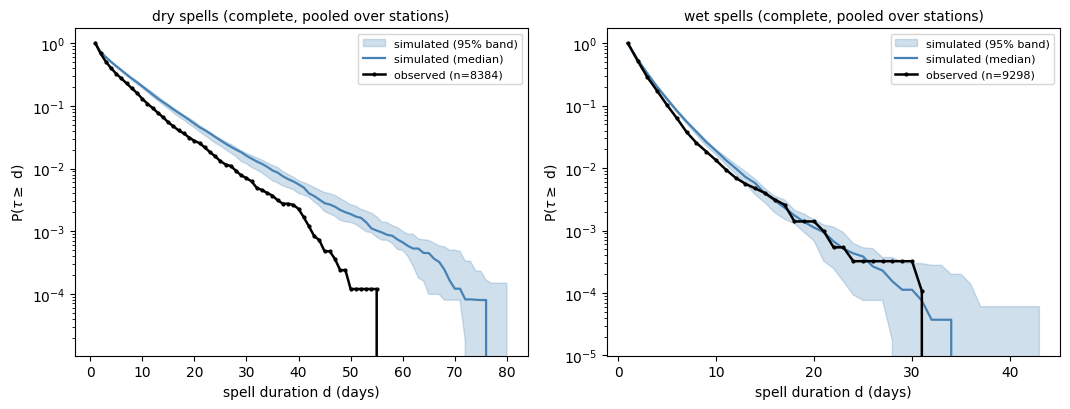

In [9]:
plot_spell_survival_obs_vs_sim(
    obs_blocks, sims,
    filename="diag_spell_survival.pdf",
);

## 6. Sensitivity to the missing-data pattern

**What is computed.** Every simulated replicate is masked with the observed missingness: $R^{\mathrm{sim}}_{n,j}$ is set to NaN whenever station $j$ does not record at day $n$, which forces the simulated record sets to equal the observed $\mathcal{T}_j$ — hence the same index sets $\mathcal{T}_j \cap \mathcal{T}_{j'}$ and $\mathcal{O}_n$ in every formula of sections 2–4. The key envelopes are then recomputed: blue = full simulations, orange = masked simulations, black = observed.

**How to read it.** If the orange and blue bands coincide, missing data only adds sampling noise and the comparisons above are safe as they are. If they differ, the orange band is the honest reference for the observed dots (identical station-days on both sides).

**What a mismatch means.** A systematic blue/orange difference means the missingness pattern is *informative* for that statistic (e.g. stations missing precisely in years that were unusually dry, or uneven station coverage across distances); conclusions should then be read against the masked band only.

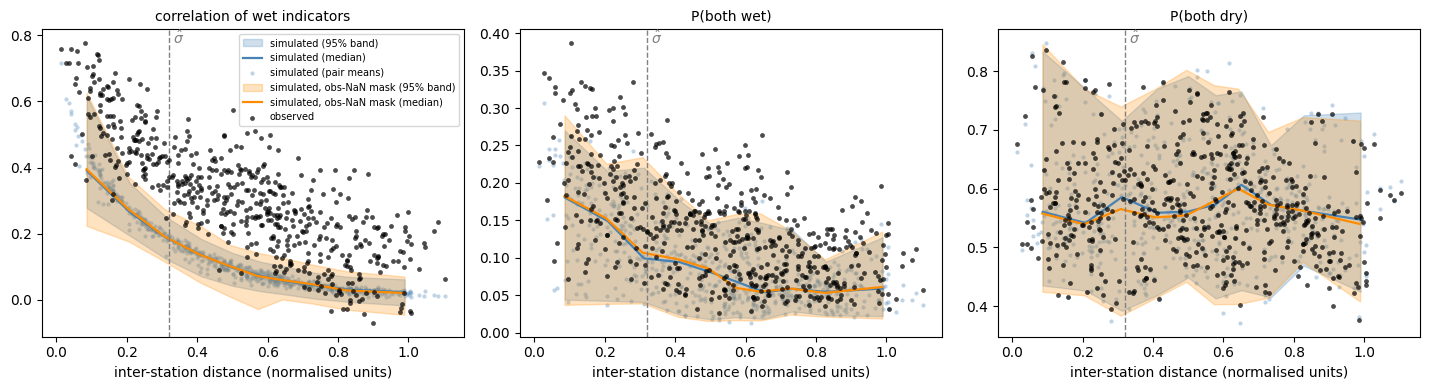

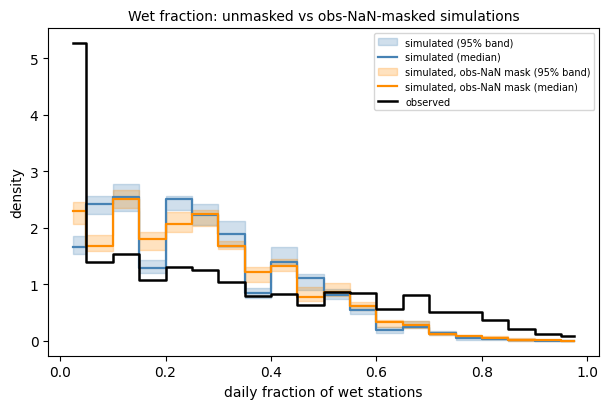

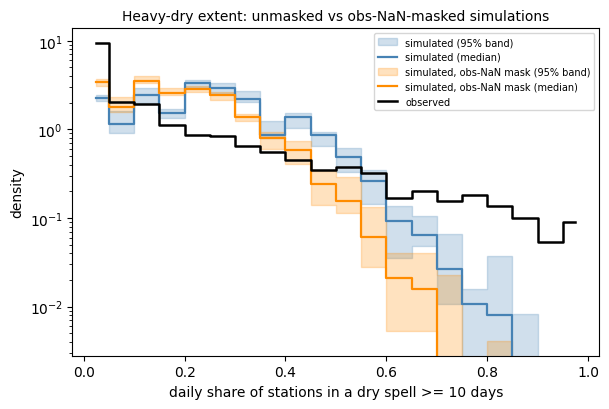

In [10]:
sims_masked = [mask_like_obs(bl, obs_blocks) for bl in sims]

# Pairwise dependence vs distance: unmasked (blue) vs masked (orange) bands.
sim_pairs_masked = [pairwise_occurrence_stats(bl, params_by_station) for bl in sims_masked]
plot_pairwise_stat_vs_distance(
    obs_pairs, sim_pairs,
    sim_dfs_alt=sim_pairs_masked,
    sigma_marker=SIGMA_HAT,
    filename="diag_sensitivity_pairwise_nan_mask.pdf",
)

# Daily wet fraction.
sim_wf_masked = [daily_wet_fraction(bl) for bl in sims_masked]
plot_fraction_distribution(
    obs_wf, sim_wf,
    sim_values_list_alt=sim_wf_masked,
    xlabel="daily fraction of wet stations",
    title="Wet fraction: unmasked vs obs-NaN-masked simulations",
    filename="diag_sensitivity_wet_fraction_nan_mask.pdf",
)

# Heavy-dry spatial extent.
sim_ext_masked = [heavy_dry_daily_fraction(bl, HEAVY_DRY_MIN_DAYS) for bl in sims_masked]
plot_fraction_distribution(
    obs_ext, sim_ext,
    sim_values_list_alt=sim_ext_masked,
    log_y=True,
    xlabel=f"daily share of stations in a dry spell >= {HEAVY_DRY_MIN_DAYS} days",
    title="Heavy-dry extent: unmasked vs obs-NaN-masked simulations",
    filename="diag_sensitivity_heavy_extent_nan_mask.pdf",
);

## Limitations & further ideas

- **No within-season drift**: $q^{(r)}$ and $\sigma$ are constant across March–May (inherited from the single-site model); a seasonal modulation could be added if the diagnostics computed per month differ.
- **Temporal structure of the latent field**: the daily fields $Y_n$ are i.i.d., so all temporal persistence comes from the duration model. Lag-1 *cross*-correlations (wet$_j$ today vs wet$_k$ tomorrow, vs distance) would detect rain advection that this model cannot represent.
- **Map snapshots**: daily maps of the station states during one major observed/simulated drought event would complement the rasters of section 1.
- **Covariance family**: a Matérn covariance or anisotropy if section 2 shows a shape mismatch; a nugget term if short-distance dependence is overestimated.
- **Distances** are in normalised coordinates (comparable to $\hat\sigma$); switching to km is immediate since every diagnostic only needs a distance matrix.